In [1]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [2]:
from binning_process.monotonic_binning import compare_methods, IsotonicBinner, QuantileMonotonicBinner, DecisionTreeBinner, ChiMergeBinner, MDLPBinner

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Dataset: N=5000, bad_rate=46.42%
Missing=200, Special(-1)=50


────────────────────────────────────────────────────────────
  BẮT ĐẦU enforce_monotonic_traced
  Feature   : feature
  Direction : descending
  Cuts ban đầu: [5825.54, 8009.64, 11290.56, 12934.61, 14537.44, 16300.64, 18206.09, 20146.64, 22295.64]
────────────────────────────────────────────────────────────
  Bước 0 (ban đầu): 10 bins | Event rates: ['95.1%', '94.6%', '90.8%', '88.4%', '76.3%', '75.2%', '67.8%', '63.2%', '52.8%', '13.4%']

  ✓ MONOTONIC đạt được sau 0 lần gộp.
  Cuts cuối: [5825.54, 8009.64, 11290.56, 12934.61, 14537.44, 16300.64, 18206.09, 20146.64, 22295.64]
  Event rates cuối: ['95.1%', '94.6%', '90.8%', '88.4%', '76.3%', '75.2%', '67.8%', '63.2%', '52.8%', '13.4%']
────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────
  BẮT ĐẦU enforce_monotonic_traced
  Feature   : feature
  Direction : descending
  Cuts ban đầu: [np.float64(6043.72)

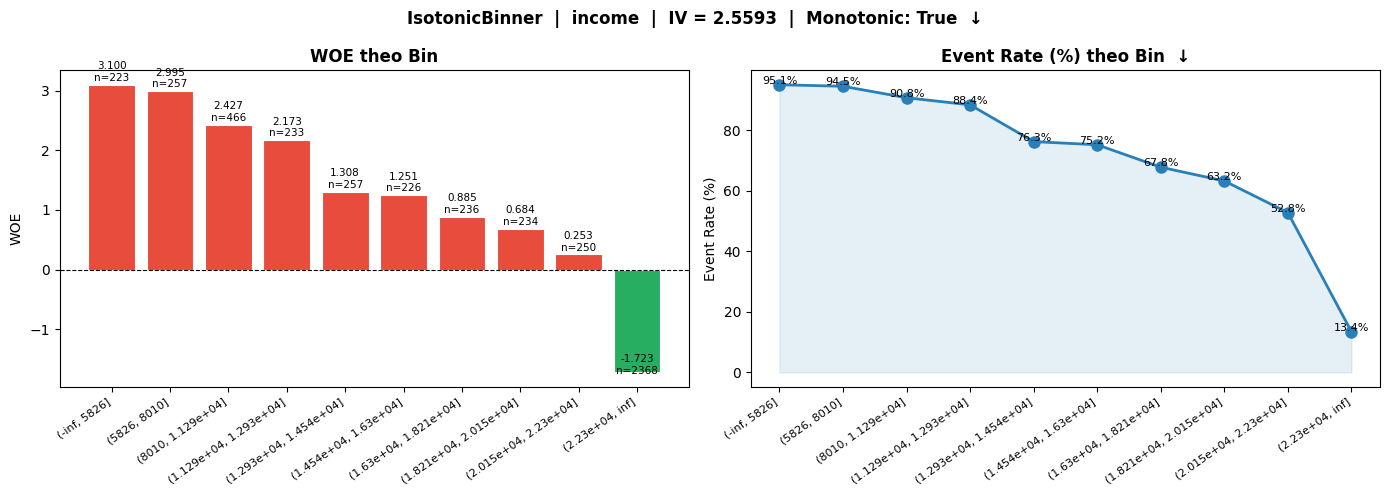

In [33]:
np.random.seed(42)
N = 5_000

# Giả lập dữ liệu credit: income có quan hệ nghịch với bad rate
income   = np.random.lognormal(mean=10, sigma=0.8, size=N)
bad_prob = 1 / (1 + np.exp((income - 22000) / 6000))
bad      = (np.random.rand(N) < bad_prob).astype(int)

income_s = pd.Series(income, name="income")
income_s.iloc[:200] = np.nan   # 4% missing
income_s.iloc[200:250] = -1    # special value
y_s = pd.Series(bad)

print(f"Dataset: N={N}, bad_rate={bad.mean():.2%}")
print(f"Missing={income_s.isna().sum()}, Special(-1)={(income_s==-1).sum()}\n")

# ── So sánh 5 methods ──────────────────────────────────────────────────
result = compare_methods(
    x=income_s, y=y_s,
    feature_name="income",
    max_bins=10,
    special_values=[-1],
)

# ── Xem chi tiết 1 method ─────────────────────────────────────────────
print("Chi tiết IsotonicBinner:")
b1 = IsotonicBinner(feature_name="income", max_bins=10, special_values=[-1])
b1.fit(income_s, y_s)
print(b1.summary().to_string(index=False))
print(f"\nCut-points: {[round(c,1) for c in b1.cuts_]}")
print(f"Monotonic : {b1.is_monotonic()} | Direction: {b1.direction_}")

print("\nChi tiết DecisionTreeBinner:")
b3 = DecisionTreeBinner(feature_name="income", max_bins=10, special_values=[-1])
b3.fit(income_s, y_s)
print(b3.summary().to_string(index=False))

# ── Transform sang WOE ────────────────────────────────────────────────
woe_vals = b1.transform(income_s)
print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# ── Plot ──────────────────────────────────────────────────────────────
fig1 = b1.plot()
plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
print("\nĐã lưu: plot_isotonic.png")
plt.show()

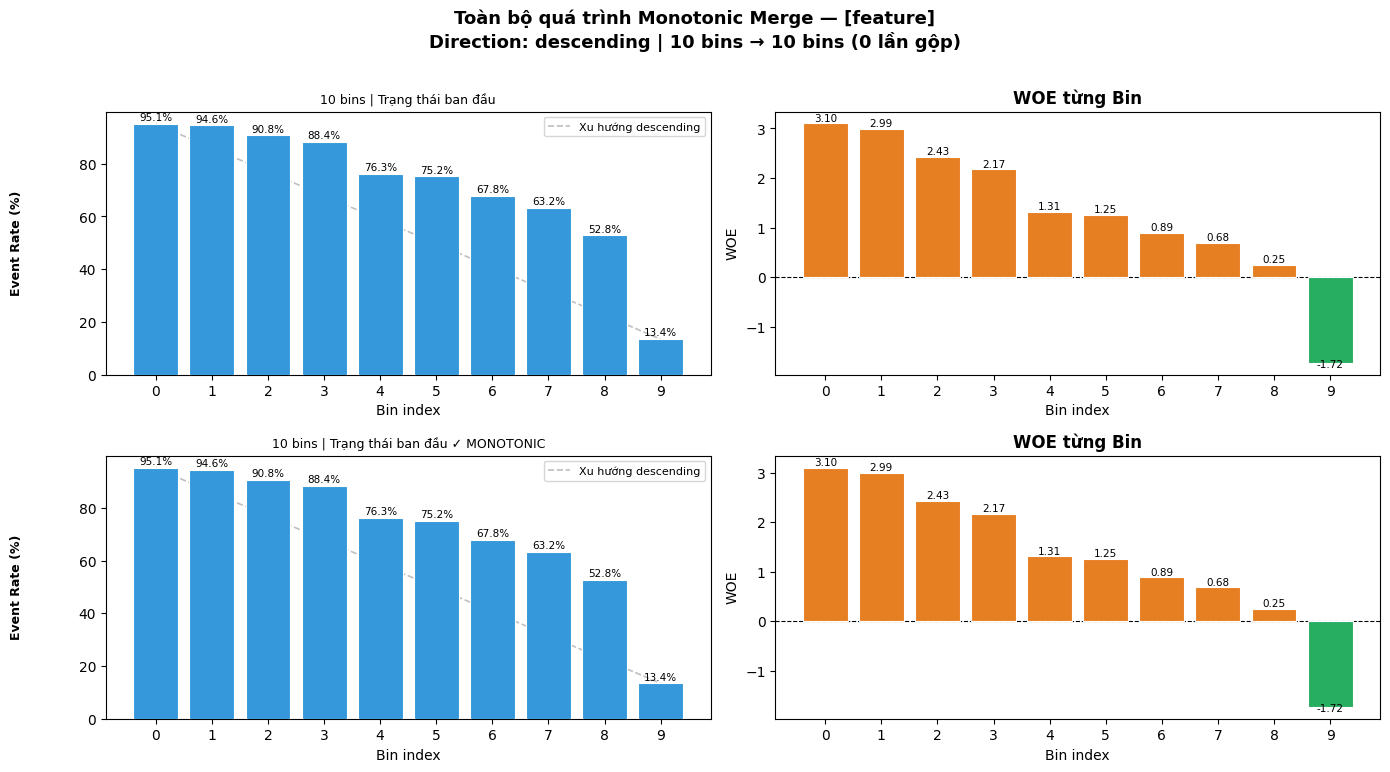

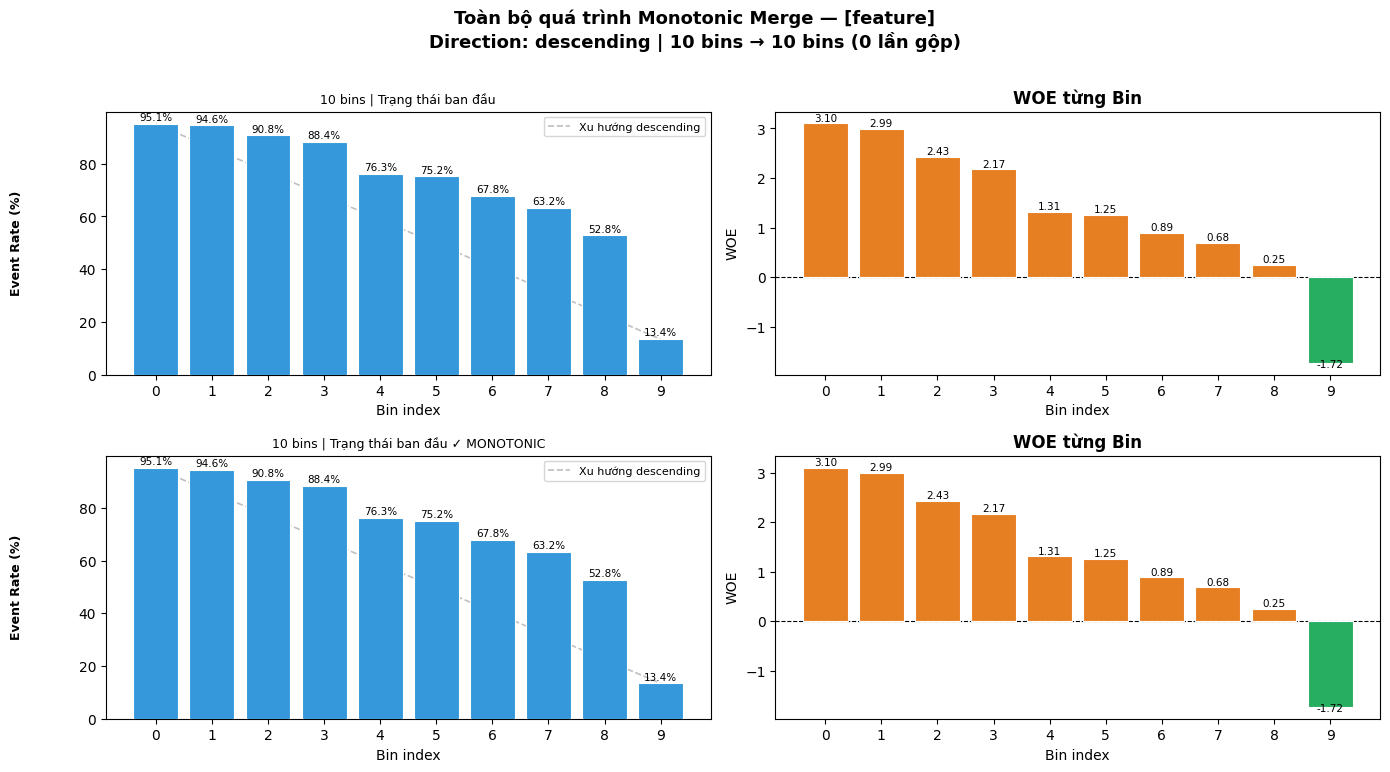

In [34]:
b1.trace_.plot_steps()

In [10]:
data = pd.read_csv(r"D:\Data\credit_scoring_example_data\loan_data_2007_2014.csv")

In [11]:
# create a new column based on the loan_status column that will be our target variable
data['bad_loan'] = np.where(data.loc[:, 'loan_status'].isin(['Charged Off', 'Default', 'Late (31-120 days)',
                                        'Does not meet the credit policy. Status:Charged Off']), 0, 1)
# Drop the original 'loan_status' column
data.drop(columns = ['loan_status'], inplace = True)
data.drop('Unnamed: 0', inplace=True, axis=1)

In [12]:
X = data.drop('bad_loan', axis = 1)
y = data['bad_loan']

In [16]:
y.value_counts()

bad_loan
1    415317
0     50968
Name: count, dtype: int64

In [18]:
X['int_rate']

0         10.65
1         15.27
2         15.96
3         13.49
4         12.69
          ...  
466280    14.47
466281    19.97
466282    16.99
466283     7.90
466284    19.20
Name: int_rate, Length: 466285, dtype: float64

In [28]:
X['annual_inc']

0          24000.0
1          30000.0
2          12252.0
3          49200.0
4          80000.0
            ...   
466280    110000.0
466281     78000.0
466282     46000.0
466283     83000.0
466284     46000.0
Name: annual_inc, Length: 466285, dtype: float64


────────────────────────────────────────────────────────────
  BẮT ĐẦU enforce_monotonic_traced
  Feature   : feature
  Direction : ascending
  Cuts ban đầu: [27500.0, 33500.0, 38000.0, 42000.0, 46000.0]
────────────────────────────────────────────────────────────
  Bước 0 (ban đầu): 6 bins | Event rates: ['84.8%', '85.9%', '86.2%', '86.6%', '87.3%', '90.1%']

  ✓ MONOTONIC đạt được sau 0 lần gộp.
  Cuts cuối: [27500.0, 33500.0, 38000.0, 42000.0, 46000.0]
  Event rates cuối: ['84.8%', '85.9%', '86.2%', '86.6%', '87.3%', '90.1%']
────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────
  BẮT ĐẦU enforce_monotonic_traced
  Feature   : feature
  Direction : ascending
  Cuts ban đầu: [np.float64(28000.0), np.float64(41600.0), np.float64(49000.0), np.float64(55000.0), np.float64(75000.0), np.float64(88960.0), np.float64(105000.0), np.float64(120000.0)]
────────────────────────────────────────────────────────────
  Bước 0 (b

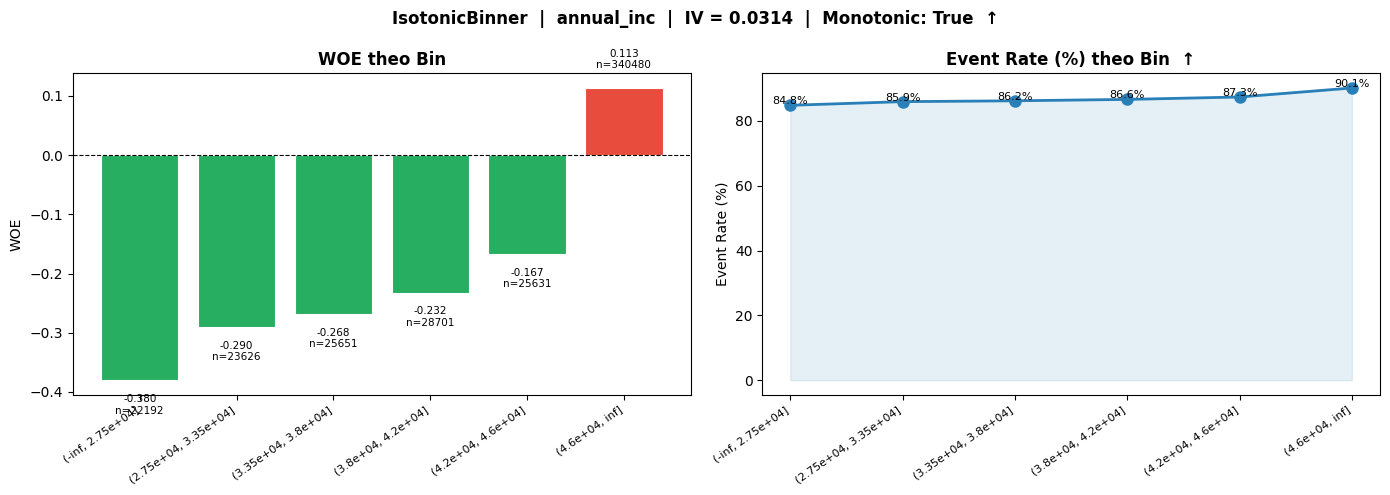

In [ ]:
val = X['annual_inc']
max_bins = 6
result = compare_methods(
    x=val, y=y,
    feature_name="income",
    max_bins=max_bins,
    special_values=[-1],
)

# ── Xem chi tiết 1 method ─────────────────────────────────────────────
print("Chi tiết IsotonicBinner:")
b1 = IsotonicBinner(feature_name="annual_inc", max_bins=max_bins, special_values=[-1])
b1.fit(val, y)
print(b1.summary().to_string(index=False))
print(f"\nCut-points: {[round(c,1) for c in b1.cuts_]}")
print(f"Monotonic : {b1.is_monotonic()} | Direction: {b1.direction_}")

print("\nChi tiết DecisionTreeBinner:")
b3 = DecisionTreeBinner(feature_name="annual_inc", max_bins=max_bins, special_values=[-1])
b3.fit(val, y)
print(b3.summary().to_string(index=False))

# # ── Transform sang WOE ────────────────────────────────────────────────
# woe_vals = b1.transform(val)
# print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# # ── Plot ──────────────────────────────────────────────────────────────
# fig1 = b1.plot()
# plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
# print("\nĐã lưu: plot_isotonic.png")
# plt.show()

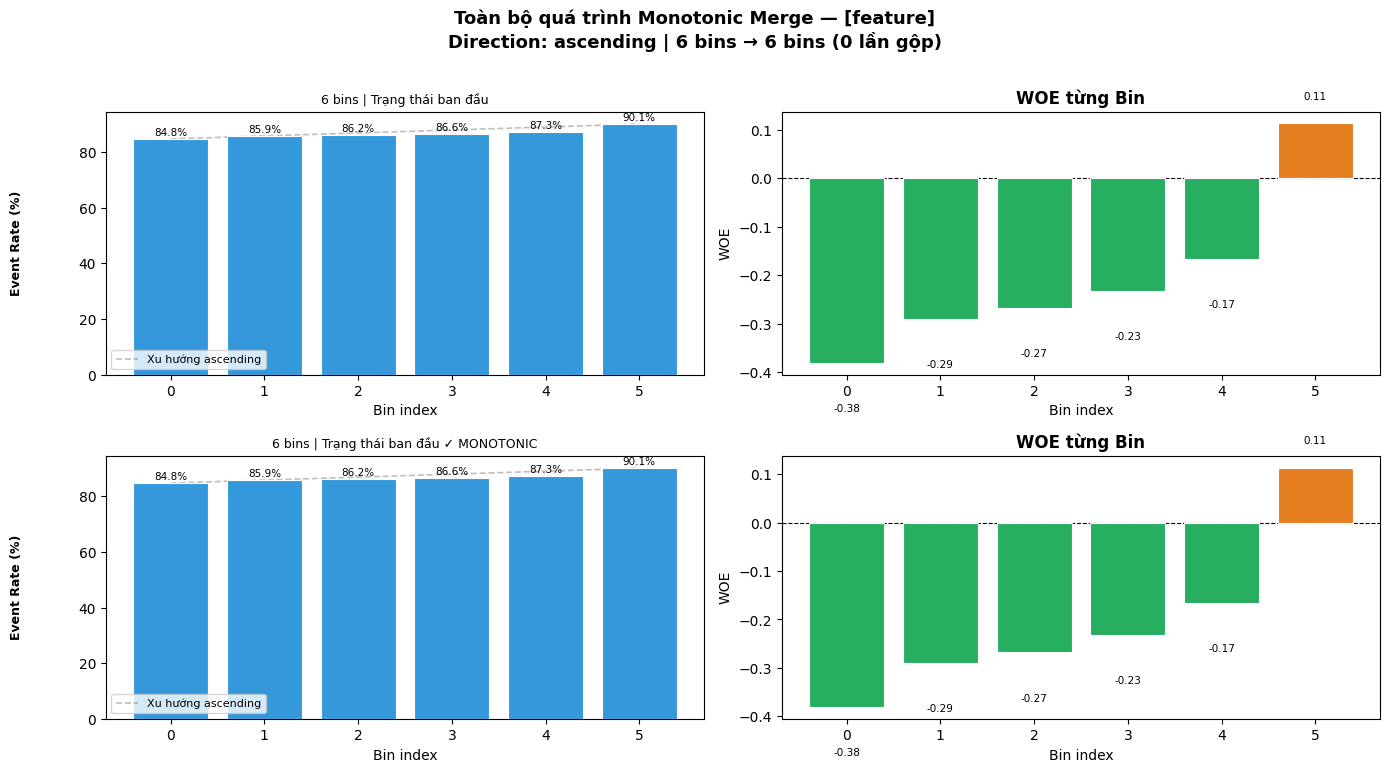

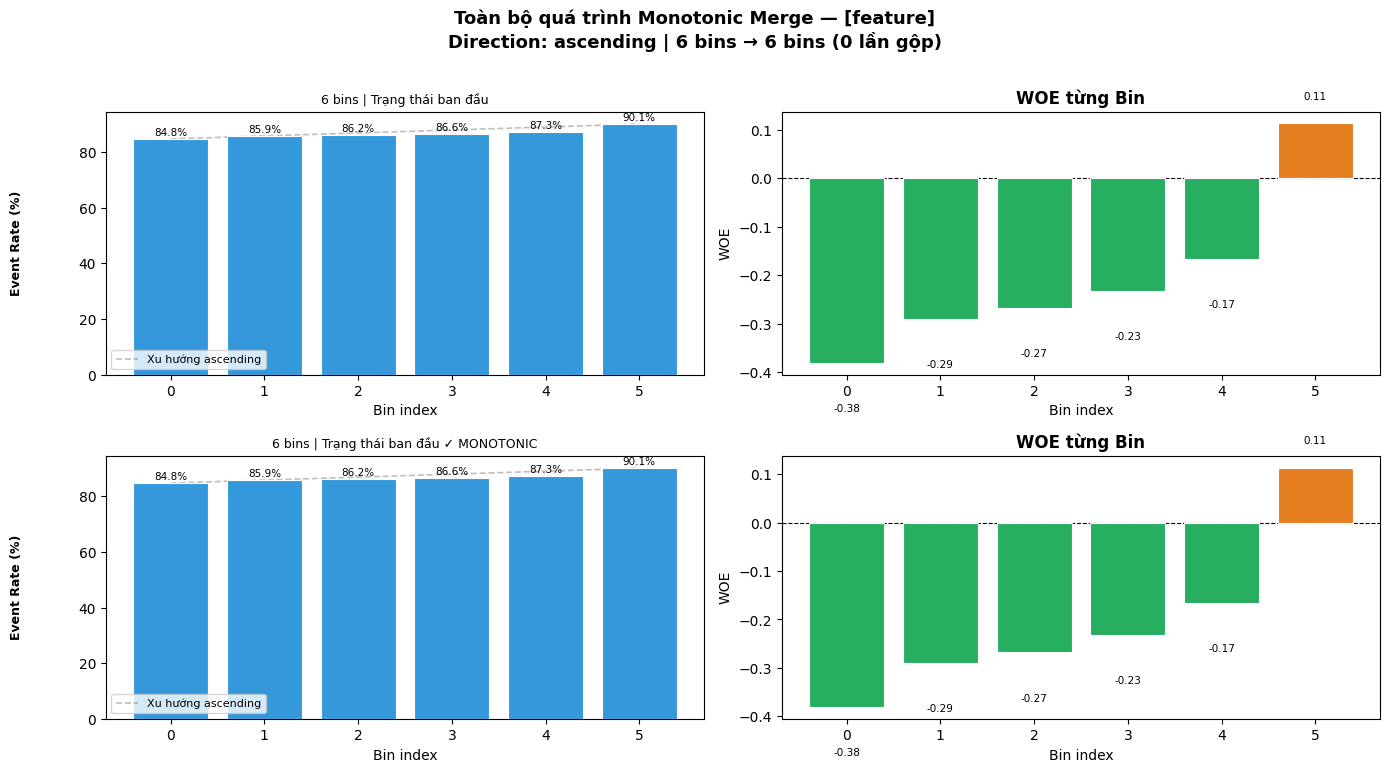

In [45]:
b1.trace_.plot_steps()

In [41]:
result

,Method,IV,n_bins,Monotonic,Direction,IV_Rating,Cuts
0,4. ChiMerge,0.0543,6,✓,ascending,Yếu,"[37000.0, 45000.0, 60000.0, 80000.0, 103000.0]"
1,2. QuantileMonotonic,0.0534,9,✓,ascending,Yếu,"[28000.0, 41600.0, 49000.0, 55000.0, 75000.0, ..."
2,5. MDLP,0.0530,6,✓,ascending,Yếu,"[27868.53, 42499.49, 60045.5, 66097.5, 80046.22]"
3,3. DecisionTree,0.0362,6,✓,ascending,Yếu,"[28188.5, 36481.5, 40311.0, 45751.24, 50421.5]"
4,1. IsotonicBinner,0.0314,6,✓,ascending,Yếu,"[27500.0, 33500.0, 38000.0, 42000.0, 46000.0]"


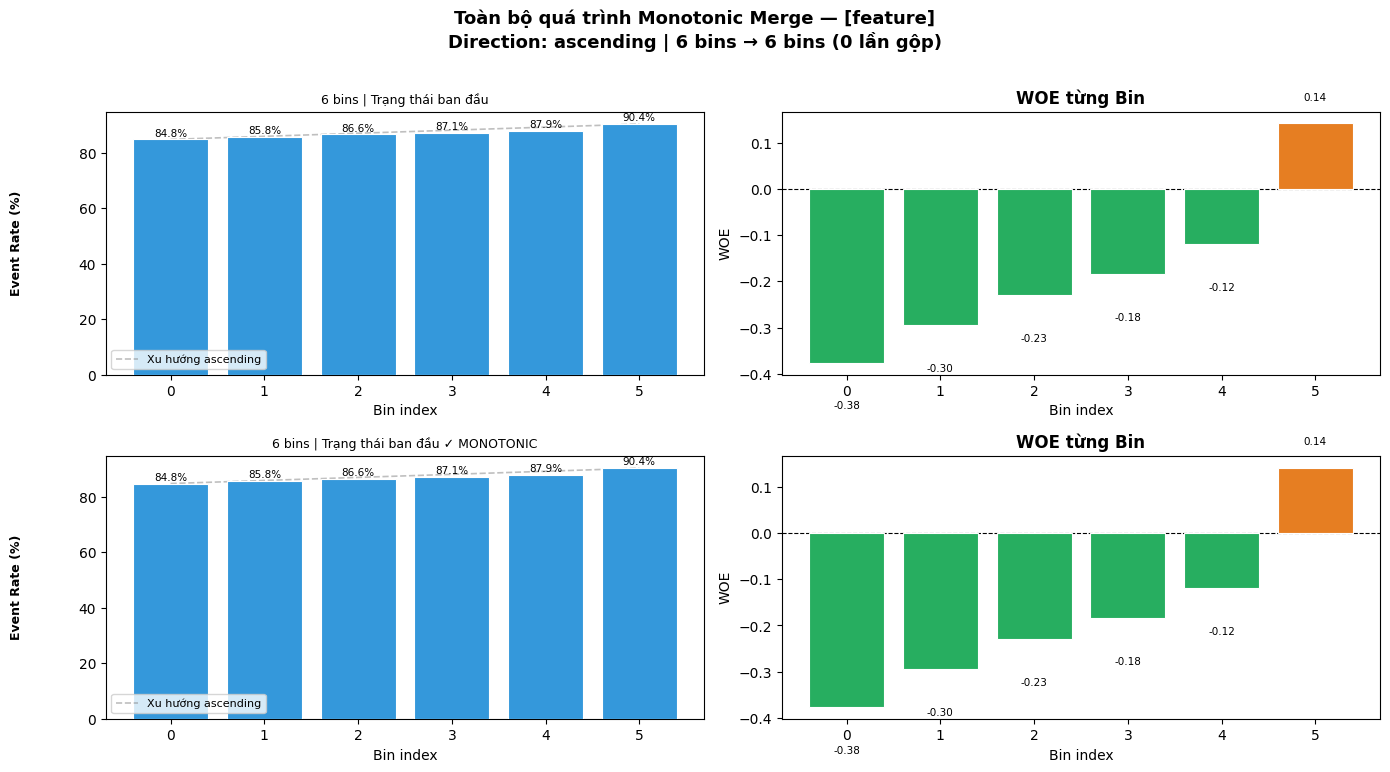

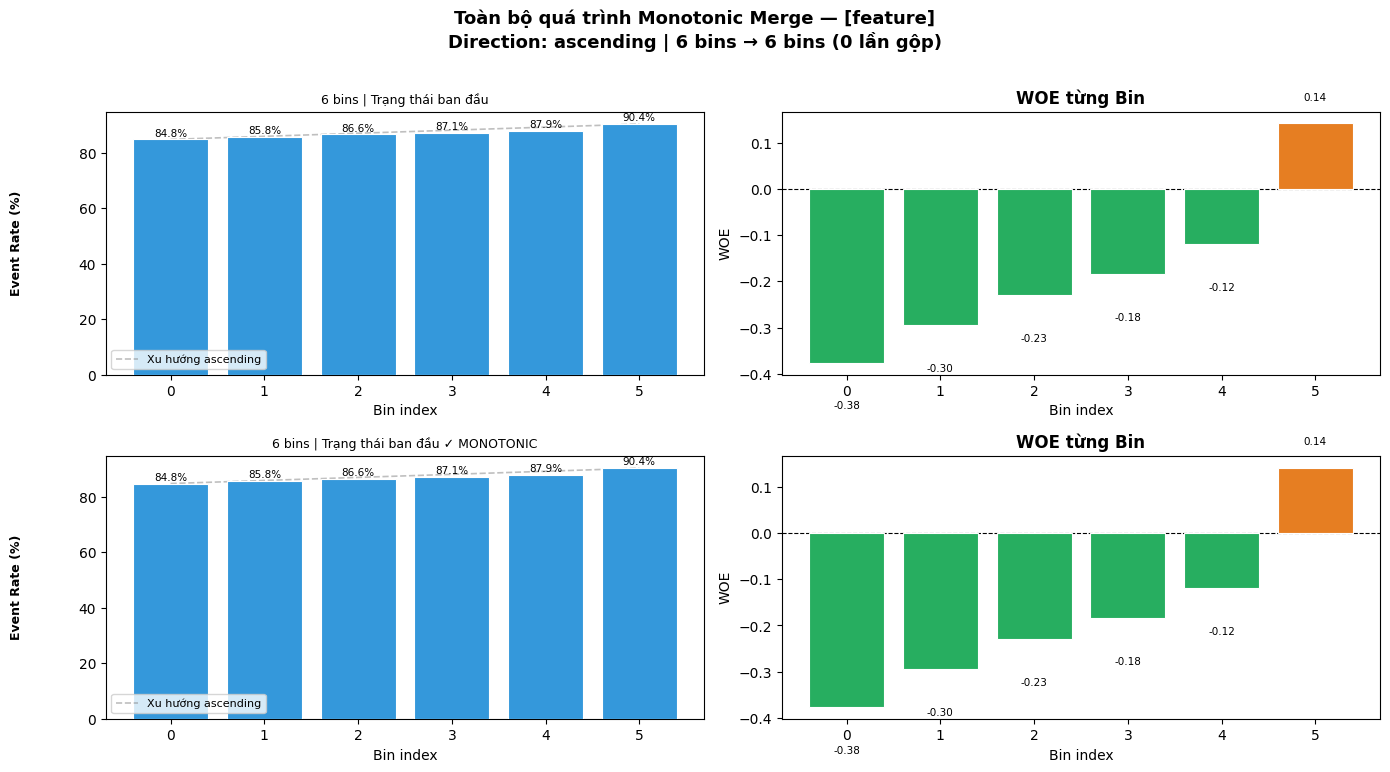

In [43]:
b3.trace_.plot_steps()

In [ ]:
print("\nChi tiết DecisionTreeBinner:")
b4 = ChiMergeBinner(feature_name="income", max_bins=max_bins, special_values=[-1])
b3.fit(val, y)
print(b3.summary().to_string(index=False))